In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings
from xgboost import XGBRegressor

# 경고 메시지 무시
warnings.filterwarnings('ignore', category=FutureWarning)

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.read_csv('data.csv')

# 1. 컬럼명 변경 (코드 호환성을 위해)
df = df.rename(columns={
    '시장가치': 'TM_시장가치_EUR',
    '부상일수': 'InjuryDays',
    '선수명': 'name_key'
})

# 2. 데이터 클리닝 함수 정의 (%, - 처리)
def clean_numeric(value):
    if isinstance(value, str):
        if '%' in value:
            return float(value.replace('%', ''))
        if value.strip() == '-':
            return 0.0
        try:
            return float(value)
        except ValueError:
            return np.nan
    return value

# 3. 전체 데이터에 클리닝 적용
# 문자열 컬럼을 제외한 모든 컬럼을 숫자로 변환
cols_to_exclude = ['리그', '시즌', 'name_key', '생년월일', '포지션']
for col in df.columns:
    if col not in cols_to_exclude:
        df[col] = df[col].apply(clean_numeric)

# 5대 리그 필터링
top_5_leagues = ['Bundesliga', 'LaLiga', 'Premier League', 'Serie A', 'Ligue 1']
df = df[df['리그'].isin(top_5_leagues)].copy()

# 기본 전처리
df['TM_시장가치_EUR'] = pd.to_numeric(df['TM_시장가치_EUR'], errors='coerce')
df['InjuryDays'] = pd.to_numeric(df['InjuryDays'], errors='coerce').fillna(0)
df.dropna(subset=['TM_시장가치_EUR', '포지션'], inplace=True)
df = df[df['TM_시장가치_EUR'] > 0]
df = df[df['포지션'] != '골키퍼'].copy()

print(f"전처리 완료. 분석 대상 데이터: {len(df)}건")

전처리 완료. 분석 대상 데이터: 11637건


In [3]:
print("피쳐 엔지니어링을 시작합니다...")

df.sort_values(by=['name_key', '시즌'], inplace=True)

df['나이_제곱'] = df['시즌종료시점만나이'] ** 2

stats_for_change = ['득점', '어시스트', '기회 창출', '슛', '태클', '가로채기', '터치', '성공한 패스']

for stat in stats_for_change:
    # 해당 스탯이 df에 있는지 확인 후 실행
    if stat in df.columns:
        df[f'전시즌_{stat}'] = df.groupby('name_key')[stat].shift(1).fillna(0)
        df[f'{stat}_변화량'] = df[stat] - df[f'전시즌_{stat}']
    else:
        print(f"경고: '{stat}' 컬럼이 df에 없어 변화량을 계산할 수 없습니다.")

# 컬럼 존재 여부 확인 후 계산
if '득점_변화량' in df.columns:
    df['나이x득점_변화량'] = (df['시즌종료시점만나이'] * df['득점_변화량'])
if '슛' in df.columns and '득점' in df.columns:
    df['슛_대비_득점율'] = np.divide(df['득점'], df['슛'], out=np.zeros_like(df['득점'], dtype=float), where=df['슛']!=0)
    
df['전시즌_시장가치_EUR'] = df.groupby('name_key')['TM_시장가치_EUR'].shift(1).fillna(0)
df['log_전시즌_시장가치'] = np.log1p(df['전시즌_시장가치_EUR'])
df['log_현재_시장가치'] = np.log1p(df['TM_시장가치_EUR'])
df['시장가치_변화량'] = df['TM_시장가치_EUR'] - df['전시즌_시장가치_EUR']

print("피쳐 엔지니어링 완료!")

피쳐 엔지니어링을 시작합니다...
피쳐 엔지니어링 완료!


In [4]:
# Cell 4: 포지션 그룹핑 및 최적 파라미터 정의

def group_position_detailed(pos):
    pos_str = str(pos).lower()
    if '중앙 수비수' in pos_str: return '중앙 수비수'
    if '수비형 미드필더' in pos_str: return '수비형 미드필더'
    if '공격형 미드필더' in pos_str: return '공격형 미드필더'
    if '중앙 미드필더' in pos_str: return '중앙 미드필더'
    if '윙어' in pos_str: return '윙어'
    if '스트라이커' in pos_str or '중앙 공격수' in pos_str: return '스트라이커'
    
    # [수정] 측면 미드필더와 측면 수비수 구분
    if '왼쪽 미드필더' in pos_str or '오른쪽 미드필더' in pos_str: return '측면 미드필더'
    if '왼쪽 수비수' in pos_str or '오른쪽 수비수' in pos_str: return '측면 수비수'
    
    return '기타'

df['포지션_그룹'] = df['포지션'].apply(group_position_detailed)
df = df[df['포지션_그룹'] != '기타']

# 제공해주신 베스트 파라미터 (8개 포지션)
best_params_per_position = {
    '공격형 미드필더': {
        'n_estimators': 1900,
        'learning_rate': 0.020762320977301275,
        'max_depth': 13,
        'subsample': 0.3856052273527386,
        'colsample_bytree': 0.7980135471467072,
        'reg_alpha': 0.00016282406660088258,
        'reg_lambda': 0.03482118513318421
        },
    '수비형 미드필더': {
        'n_estimators': 1400,
        'learning_rate': 0.022491096898892622,
        'max_depth': 19,
        'subsample': 0.427399045217705,
        'colsample_bytree': 0.7536284027955273,
        'reg_alpha': 6.530905564075279e-07,
        'reg_lambda': 0.028399498223413196
        },
    '스트라이커': {
        'n_estimators': 1600,
        'learning_rate': 0.011723795540417655,
        'max_depth': 15,
        'subsample': 0.4014413443070366,
        'colsample_bytree': 0.7460919009335952,
        'reg_alpha': 1.7387604754886692e-07,
        'reg_lambda': 3.6656893204449398e-06
        },
    '윙어': {'n_estimators': 1400, 'learning_rate': 0.04132166762817925, 'max_depth': 9, 'subsample': 0.6216447365354127, 'colsample_bytree': 0.5306921156821315, 'reg_alpha': 6.592195514427946e-05, 'reg_lambda': 8.811664062461144e-06},
    '중앙 미드필더': {'n_estimators': 1600, 'learning_rate': 0.084860060235904, 'max_depth': 5, 'subsample': 0.7869147744468107, 'colsample_bytree': 0.6814027657309146, 'reg_alpha': 1.3579137923778576e-07, 'reg_lambda': 3.829970428360115e-07},
    '중앙 수비수': {'n_estimators': 1100, 'learning_rate': 0.020771872880752665, 'max_depth': 4, 'subsample': 0.5562494519644748, 'colsample_bytree': 0.398997982165777, 'reg_alpha': 0.061343450214043506, 'reg_lambda': 0.46185038844108967},
    '측면 미드필더': {'n_estimators': 1700, 'learning_rate': 0.06561899817995089, 'max_depth': 3, 'subsample': 0.675130546991308, 'colsample_bytree': 0.8366998204911843, 'reg_alpha': 3.871586781469543e-05, 'reg_lambda': 1.5542377744930896e-07},
    '측면 수비수': {'n_estimators': 1400, 'learning_rate': 0.023703783882164025, 'max_depth': 6, 'subsample': 0.9301629782976328, 'colsample_bytree': 0.5744368741577944, 'reg_alpha': 2.0849287673580608e-05, 'reg_lambda': 0.0007417703250231236}
}

print("✅ 파라미터 정의 완료.")

✅ 파라미터 정의 완료.



✨ 포지션별 챔피언 모델 학습 및 분석 시작 ✨

✨ 공격형 미드필더 분석 중... ✨
'공격형 미드필더' 챔피언 모델 학습 시작...

[📊 모델 성능 평가]
  - R-squared: 70.21%
  - RMSE: 10,653,363 EUR

[📈 주요 피쳐 Top 15]
    Importance         Feature
0     0.430379    log_전시즌_시장가치
1     0.051163       시즌종료시점만나이
2     0.039818           나이_제곱
3     0.029837  상대편 박스 내에서의 터치
4     0.021671        어시스트_변화량
5     0.021569       기회 창출_변화량
6     0.020812        가로채기_변화량
7     0.019392      성공한 패스_변화량
8     0.019318              터치
9     0.018930          터치_변화량
10    0.018427           슛_변화량
11    0.013670          태클_변화량
12    0.013331          패스 정확도
13    0.012135          득점_변화량
14    0.011675       나이x득점_변화량


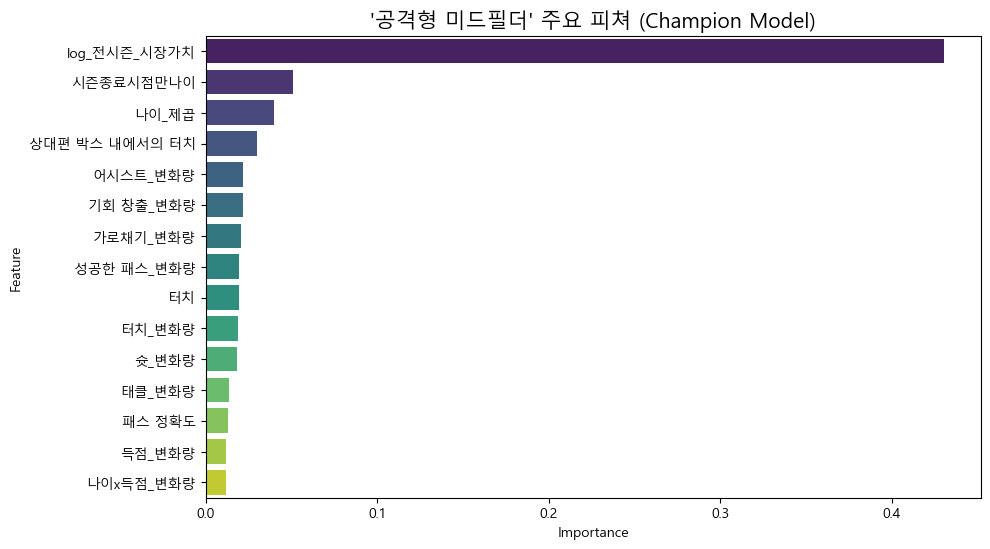


[⬆️ 과대평가 TOP 5]
                    선수명        실제_가치       예측_가치           오차
8296  philippe coutinho  19500000.00  41391324.0  21891324.00
9970       luis alberto  34333333.33  53136972.0  18803638.67
8521    roberto firmino  22666666.67  41322696.0  18656029.33
2994        nabil fekir  36000000.00  52989812.0  16989812.00
6067        amine harit   9500000.00  24033076.0  14533076.00

[⬇️ 과소평가 TOP 5]
                  선수명        실제_가치        예측_가치          오차
7197  kevin de bruyne  111666667.0   59215632.0 -52451035.0
1951    jamal musiala  140000000.0   98187320.0 -41812680.0
5399           neymar  144000000.0  103359512.0 -40640488.0
33      thomas müller   55000000.0   16607171.0 -38392829.0
3875             gavi   83333333.0   47250904.0 -36082429.0

[🎯 정확한 예측 TOP 5]
                       선수명      실제_가치         예측_가치           오차
6458   youssouf m'changama   950000.0  1.027283e+06   77283.1875
2438         gabriel pires  3250000.0  3.338659e+06   88658.7500
1200             max 

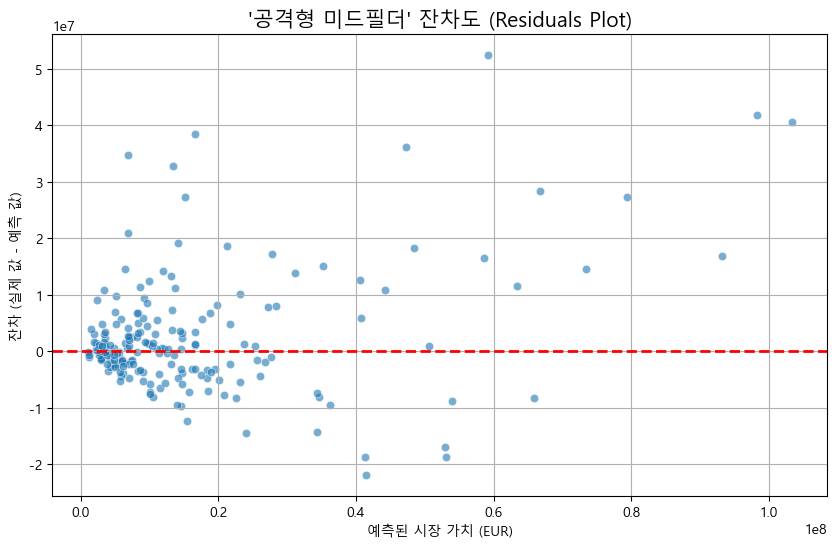


✨ 수비형 미드필더 분석 중... ✨
'수비형 미드필더' 챔피언 모델 학습 시작...

[📊 모델 성능 평가]
  - R-squared: 70.72%
  - RMSE: 10,724,198 EUR

[📈 주요 피쳐 Top 15]
    Importance         Feature
0     0.388066    log_전시즌_시장가치
1     0.110135       시즌종료시점만나이
2     0.059428           나이_제곱
3     0.030317              터치
4     0.028564          터치_변화량
5     0.025233      성공한 패스_변화량
6     0.017817  상대편 박스 내에서의 터치
7     0.012836            막힌 슛
8     0.012713       볼 경합 성공 %
9     0.012197              반칙
10    0.012066        슛_대비_득점율
11    0.011855          성공한 패스
12    0.011242       기회 창출_변화량
13    0.011185      공중 볼 경합 성공
14    0.011043          태클_변화량


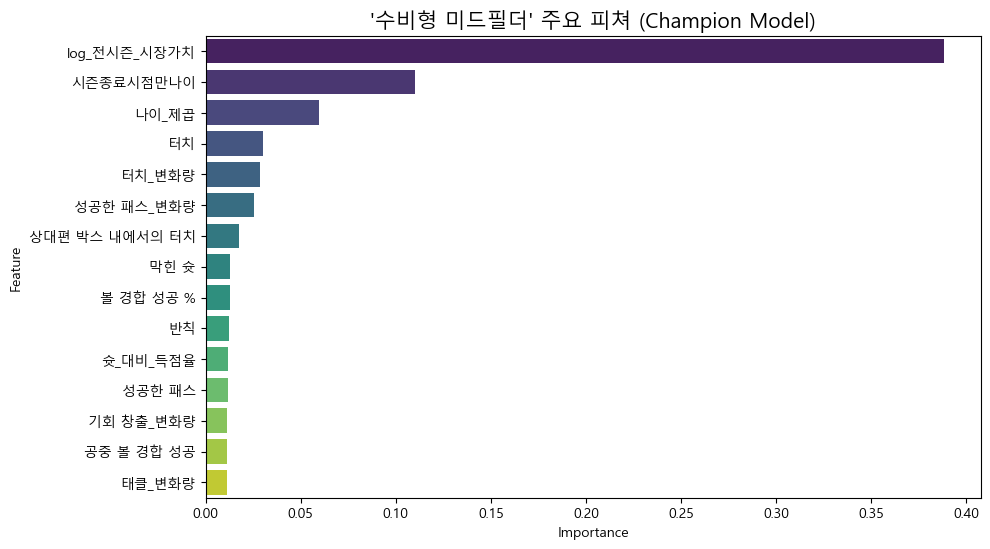


[⬆️ 과대평가 TOP 5]
                  선수명       실제_가치       예측_가치          오차
1720    leon goretzka  33333333.0  54548144.0  21214811.0
9284            allan    200000.0  17982132.0  17782132.0
6866     jordan james   7000000.0  20961424.0  13961424.0
1402  marcel sabitzer  24000000.0  37760692.0  13760692.0
1949   joshua kimmich  47500000.0  60302180.0  12802180.0

[⬇️ 과소평가 TOP 5]
                      선수명        실제_가치        예측_가치            오차
8367                allan  150000000.0  34989272.00 -1.150107e+08
3309            josé mari   63750000.0   2925387.75 -6.082461e+07
7882    christian eriksen   81000000.0  40628776.00 -4.037122e+07
8785        joao palhinha   56250000.0  26899448.00 -2.935055e+07
8995  alexis mac allister   90000000.0  60868640.00 -2.913136e+07

[🎯 정확한 예측 TOP 5]
                        선수명       실제_가치         예측_가치          오차
405        gelson fernandes   1666667.0  1.713339e+06  46672.0000
9891   francesco magnanelli    800000.0  8.481913e+05  48191.3125
5982  

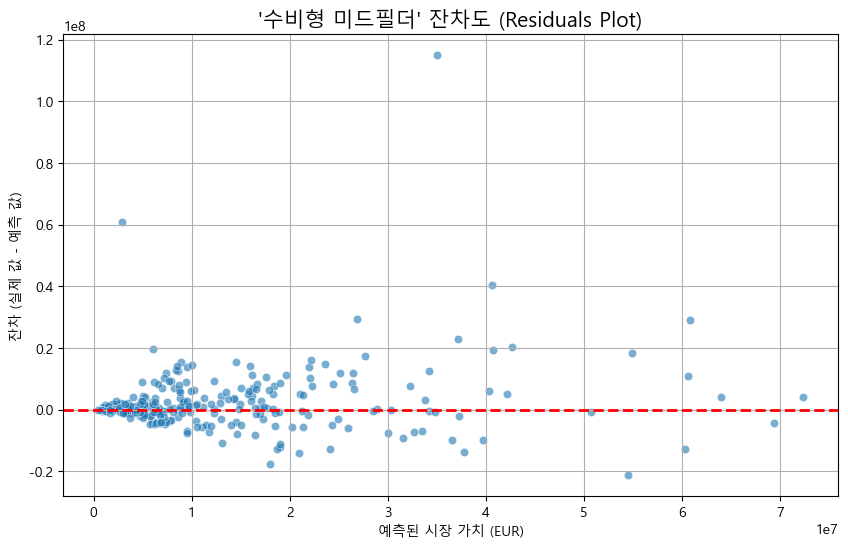


✨ 스트라이커 분석 중... ✨
'스트라이커' 챔피언 모델 학습 시작...

[📊 모델 성능 평가]
  - R-squared: 76.09%
  - RMSE: 9,537,866 EUR

[📈 주요 피쳐 Top 15]
    Importance         Feature
0     0.398097    log_전시즌_시장가치
1     0.081140       시즌종료시점만나이
2     0.056575           나이_제곱
3     0.030009  상대편 박스 내에서의 터치
4     0.023100       나이x득점_변화량
5     0.021455          득점_변화량
6     0.020169          터치_변화량
7     0.019168              반칙
8     0.018783        슛_대비_득점율
9     0.016369              퇴장
10    0.015156      성공한 패스_변화량
11    0.014527           슛_변화량
12    0.013370        어시스트_변화량
13    0.013368       기회 창출_변화량
14    0.013040          태클_변화량


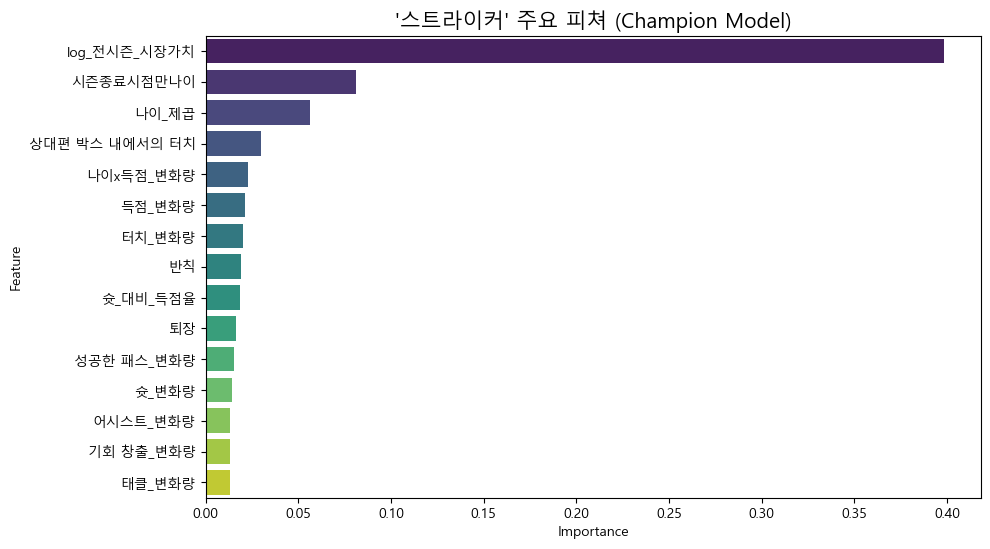


[⬆️ 과대평가 TOP 5]
                             선수명       실제_가치       예측_가치          오차
1174          robert lewandowski  47500000.0  66460184.0  18960184.0
10769            patrick cutrone   5250000.0  24147536.0  18897536.0
10277                 joao pedro  10500000.0  27800960.0  17300960.0
1808               patrik schick  22000000.0  37943856.0  15943856.0
6505   pierre-emerick aubameyang   4500000.0  19867084.0  15367084.0

[⬇️ 과소평가 TOP 5]
                            선수명        실제_가치        예측_가치          오차
5153              kylian mbappé  193333333.0  140130848.0 -53202485.0
2461               lionel messi  180000000.0  127665808.0 -52334192.0
8965              evan ferguson   60000000.0    8833790.0 -51166210.0
2201               lionel messi  120000000.0   76224592.0 -43775408.0
7     pierre-emerick aubameyang   65000000.0   21247380.0 -43752620.0

[🎯 정확한 예측 TOP 5]
                      선수명      실제_가치      예측_가치       오차
5386        enzo crivelli  4000000.0  3987975.0 -12025.0


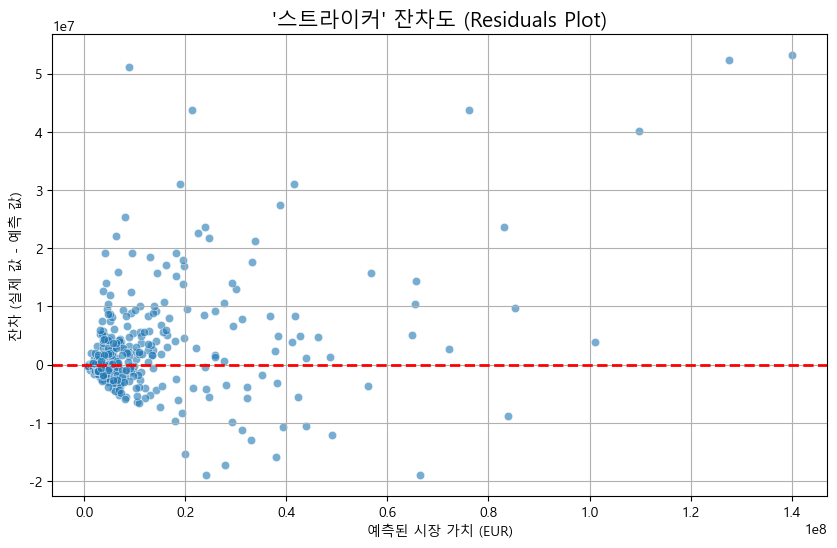


✨ 윙어 분석 중... ✨
'윙어' 챔피언 모델 학습 시작...

[📊 모델 성능 평가]
  - R-squared: 74.92%
  - RMSE: 12,805,752 EUR

[📈 주요 피쳐 Top 15]
    Importance         Feature
0     0.221624    log_전시즌_시장가치
1     0.115314  상대편 박스 내에서의 터치
2     0.064440       시즌종료시점만나이
3     0.046779           나이_제곱
4     0.033675              퇴장
5     0.030798        슛_대비_득점율
6     0.025811      성공한 패스_변화량
7     0.019548          터치_변화량
8     0.018661              회복
9     0.017793          드리블 성공
10    0.017551           슛_변화량
11    0.017027          성공한 패스
12    0.016980              반칙
13    0.016273              터치
14    0.016157          태클_변화량


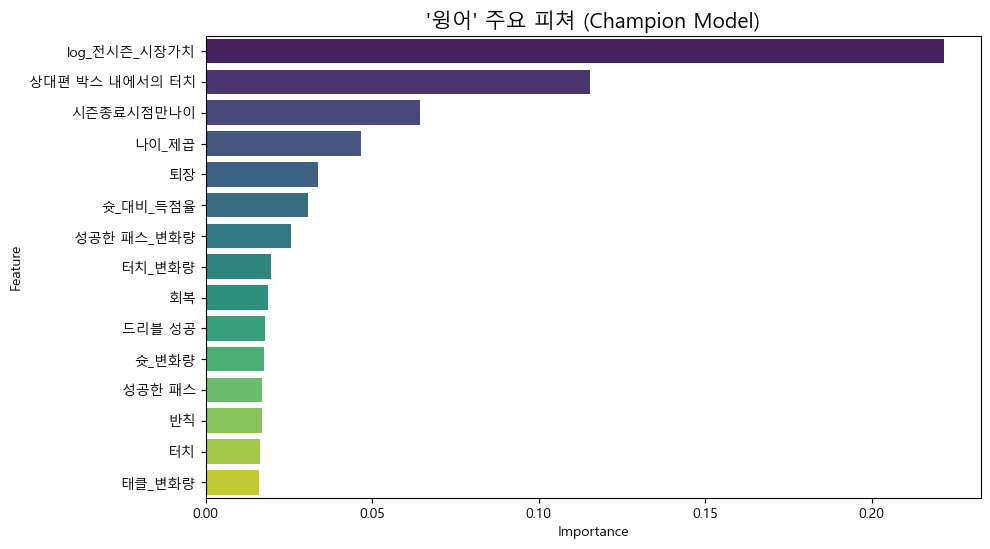


[⬆️ 과대평가 TOP 5]
                    선수명       실제_가치       예측_가치          오차
4604     arnaut danjuma   5666667.0  32846880.0  27180213.0
3323   samuel chukwueze  21666667.0  47327120.0  25660453.0
8727      mohamed salah  60000000.0  80166744.0  20166744.0
9094       jadon sancho  29000000.0  47927668.0  18927668.0
10008       musa barrow   9333333.0  25454824.0  16121491.0

[⬇️ 과소평가 TOP 5]
                  선수명        실제_가치       예측_가치          오차
4094  vinicius junior  165000000.0  73209600.0 -91790400.0
7200    mohamed salah   90000000.0  28798852.0 -61201148.0
700      jadon sancho  122333333.0  63604756.0 -58728577.0
8988      bukayo saka  150000000.0  95007352.0 -54992648.0
3706            rodri   75000000.0  32202964.0 -42797036.0

[🎯 정확한 예측 TOP 5]
                 선수명       실제_가치        예측_가치        오차
2680           jason   3000000.0   2999111.50   -888.50
7692  christian atsu   6000000.0   5976335.00 -23665.00
3631  alex berenguer  12000000.0  11963659.00 -36341.00
3703   jor

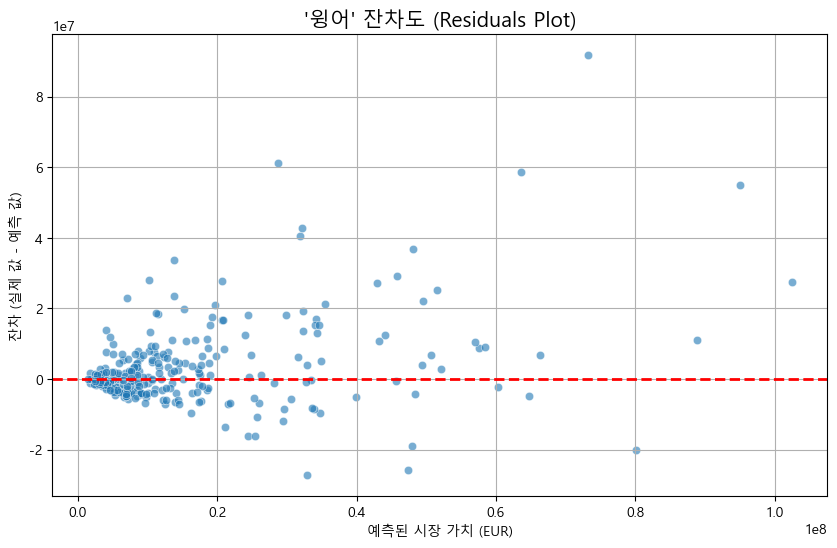


✨ 중앙 미드필더 분석 중... ✨
'중앙 미드필더' 챔피언 모델 학습 시작...

[📊 모델 성능 평가]
  - R-squared: 78.71%
  - RMSE: 6,943,247 EUR

[📈 주요 피쳐 Top 15]
    Importance         Feature
0     0.411053    log_전시즌_시장가치
1     0.142306       시즌종료시점만나이
2     0.040926              터치
3     0.034093           나이_제곱
4     0.028376      성공한 패스_변화량
5     0.022333        가로채기_변화량
6     0.019351  상대편 박스 내에서의 터치
7     0.019055          터치_변화량
8     0.018073         페널티킥 허용
9     0.014025          성공한 패스
10    0.013632          득점_변화량
11    0.013162          패스 정확도
12    0.011671              퇴장
13    0.011178              경고
14    0.009355        슛_대비_득점율


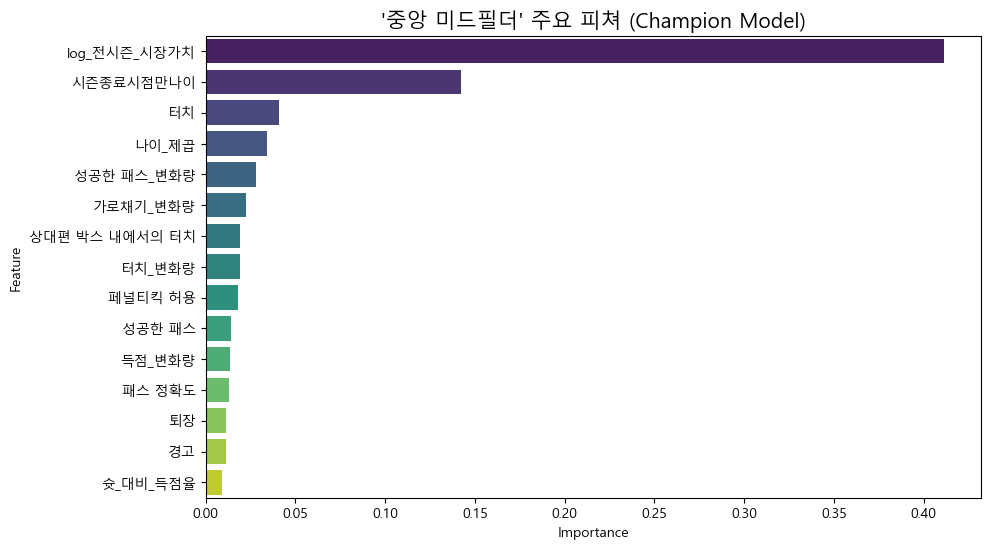


[⬆️ 과대평가 TOP 5]
                   선수명       실제_가치       예측_가치          오차
7983          jorginho  45000000.0  78079400.0  33079400.0
6262  corentin tolisso  14000000.0  44061004.0  30061004.0
2981   sergio busquets  31500000.0  46399692.0  14899692.0
8819    harvey elliott  33333333.0  47760580.0  14427247.0
8698       will hughes   5000000.0  14361430.0   9361430.0

[⬇️ 과소평가 TOP 5]
              선수명       실제_가치       예측_가치          오차
2236  saul niguez  37500000.0   4495811.5 -33004188.5
2760      rodrigo  57500000.0  28834632.0 -28665368.0
241    naby keita  57500000.0  29170132.0 -28329868.0
2210  luka modric  42500000.0  14498853.0 -28001147.0
7498     jorginho  63333333.0  36809572.0 -26523761.0

[🎯 정확한 예측 TOP 5]
                   선수명      실제_가치         예측_가치          오차
11024    miguel veloso   600000.0  5.836351e+05 -16364.9375
10548     milan badelj  1250000.0  1.267130e+06  17130.3750
7122     andrew surman  2000000.0  1.969299e+06 -30700.7500
5375   yannick cahuzac   62500

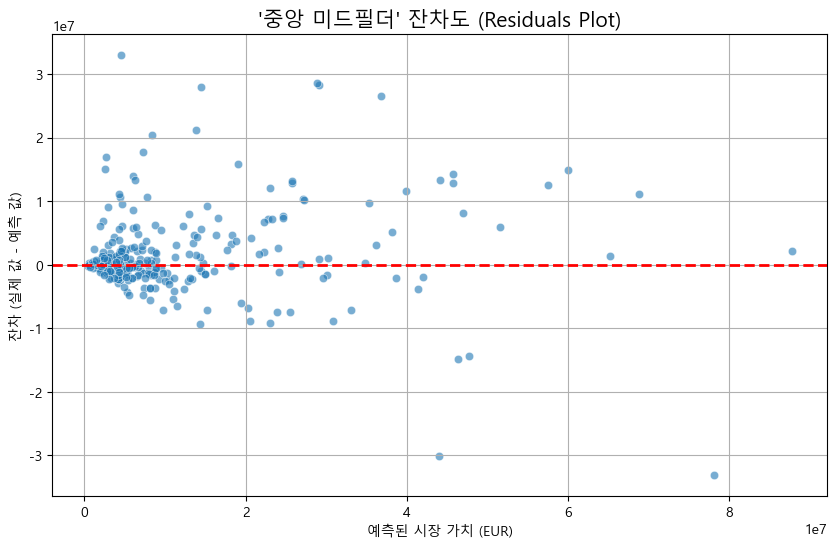


✨ 중앙 수비수 분석 중... ✨
'중앙 수비수' 챔피언 모델 학습 시작...

[📊 모델 성능 평가]
  - R-squared: 76.08%
  - RMSE: 7,370,407 EUR

[📈 주요 피쳐 Top 15]
    Importance         Feature
0     0.160635    log_전시즌_시장가치
1     0.121660           나이_제곱
2     0.119890       시즌종료시점만나이
3     0.060792          성공한 패스
4     0.036682              터치
5     0.027685  상대편 박스 내에서의 터치
6     0.024057          터치_변화량
7     0.022746      성공한 패스_변화량
8     0.018599          패스 정확도
9     0.017046        가로채기_변화량
10    0.016256      공중 볼 경합 성공
11    0.016120          태클_변화량
12    0.015276              퇴장
13    0.014706         페널티킥 허용
14    0.014472       볼 경합 성공 %


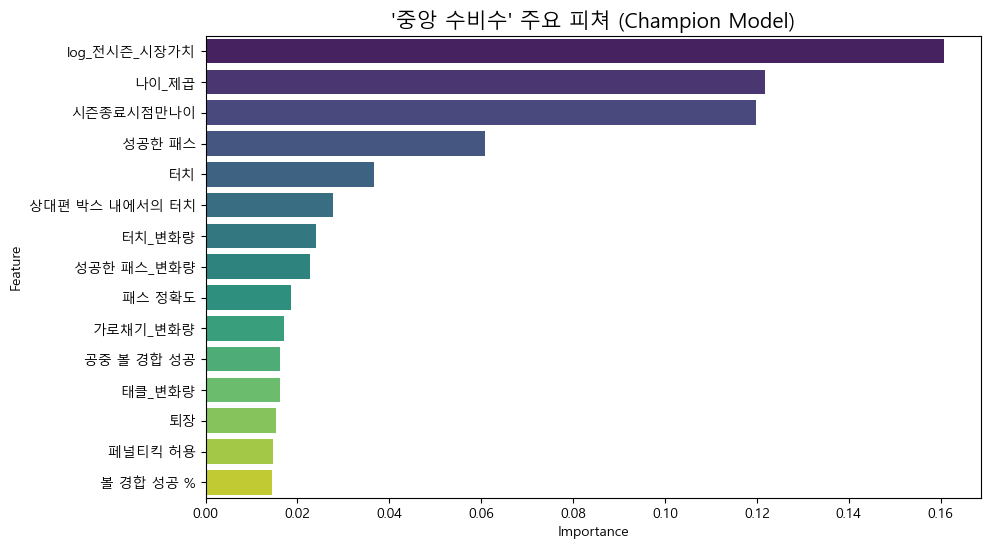


[⬆️ 과대평가 TOP 5]
                     선수명       실제_가치       예측_가치          오차
8238     aymeric laporte  45000000.0  73446944.0  28446944.0
3316     clément lenglet  35000000.0  57476796.0  22476796.0
8118           eric dier  23500000.0  37052520.0  13552520.0
10635  nikola milenkovic  21500000.0  33914252.0  12414252.0
8312     james tarkowski  22000000.0  33687576.0  11687576.0

[⬇️ 과소평가 TOP 5]
                      선수명       실제_가치        예측_가치           오차
3397               josema  63750000.0   2765802.75 -60984197.25
4114  aurélien tchouaméni  93333333.0  60273204.00 -33060129.00
2923             bernardo  76250000.0  43213072.00 -33036928.00
243        jérome boateng  41666667.0  14448885.00 -27217782.00
7002           david luiz  30000000.0   4013522.75 -25986477.25

[🎯 정확한 예측 TOP 5]
                   선수명      실제_가치        예측_가치         오차
435   dominique heintz  7500000.0  7500058.000     58.000
3614    edgar gonzález  5875000.0  5873062.500  -1937.500
3990    luis hernández  

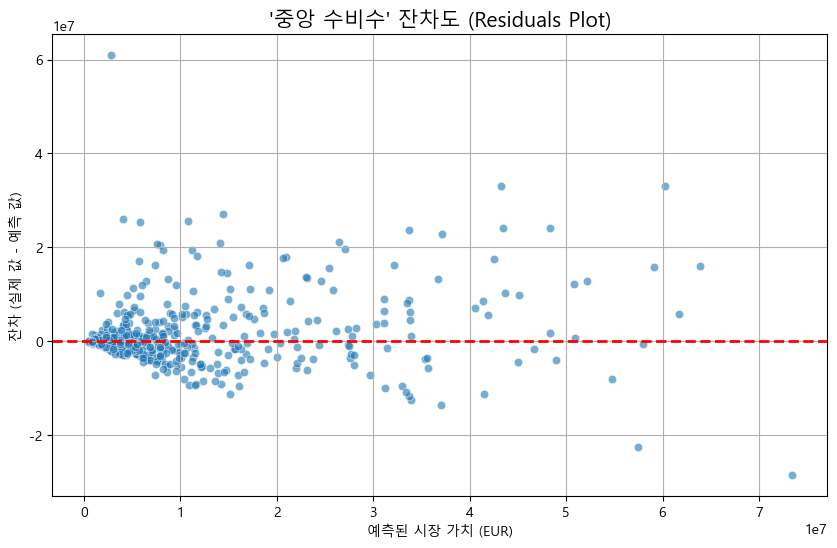


✨ 측면 미드필더 분석 중... ✨
'측면 미드필더' 챔피언 모델 학습 시작...

[📊 모델 성능 평가]
  - R-squared: 52.50%
  - RMSE: 6,736,547 EUR

[📈 주요 피쳐 Top 15]
    Importance         Feature
0     0.361180    log_전시즌_시장가치
1     0.113373       시즌종료시점만나이
2     0.113330           나이_제곱
3     0.042170  상대편 박스 내에서의 터치
4     0.028923         페널티킥 받음
5     0.021879        어시스트_변화량
6     0.021804          성공한 패스
7     0.016467       기회 창출_변화량
8     0.014154         페널티킥 허용
9     0.013640      공중 볼 경합 성공
10    0.013515            볼 뺏김
11    0.013502              퇴장
12    0.013207          득점_변화량
13    0.012672           슛_변화량
14    0.010854      성공한 패스_변화량


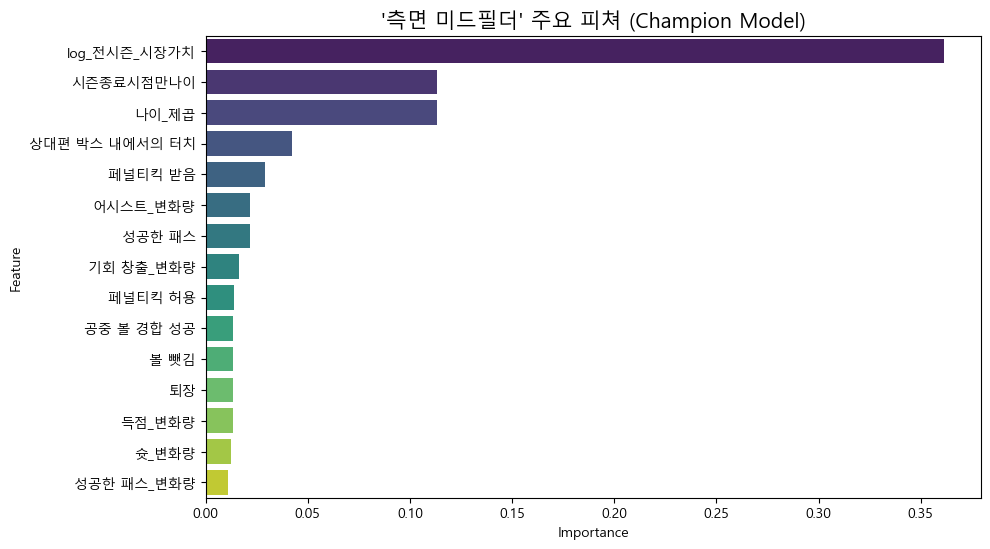


[⬆️ 과대평가 TOP 5]
                   선수명       실제_가치        예측_가치          오차
6349      aaron ramsey   2750000.0  11511089.00  8761089.00
6318        adam ounas   7500000.0  14282811.00  6782811.00
1444        borna sosa  16750000.0  22649664.00  5899664.00
4047  valery fernández   1500000.0   6927634.00  5427634.00
4457       yéremi pino     37500.0   3125463.25  3087963.25

[⬇️ 과소평가 TOP 5]
                   선수명       실제_가치        예측_가치           오차
4945    julian draxler  35000000.0   6560146.50 -28439853.50
8736   conor gallagher  45000000.0  22410780.00 -22589220.00
2073      antonio nusa  26000000.0   3734918.75 -22265081.25
4516   conor gallagher  40000000.0  21674756.00 -18325244.00
10072     aaron ramsey  34333333.0  18969460.00 -15363873.00

[🎯 정확한 예측 TOP 5]
                      선수명      실제_가치        예측_가치          오차
2235        xabier prieto  3000000.0  3016750.250   16750.250
11456     tommaso augello  1800000.0  1861512.000   61512.000
3366           luis rioja  2166667.0

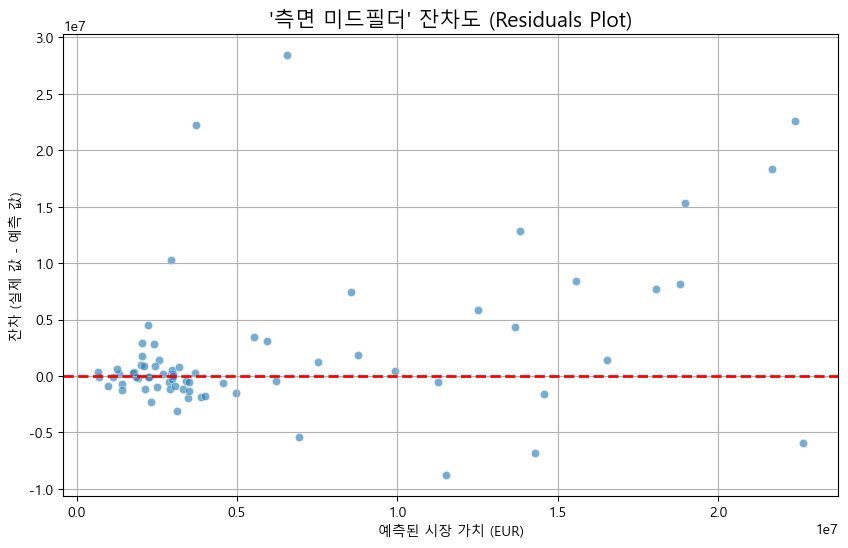


✨ 측면 수비수 분석 중... ✨
'측면 수비수' 챔피언 모델 학습 시작...

[📊 모델 성능 평가]
  - R-squared: 76.81%
  - RMSE: 6,079,912 EUR

[📈 주요 피쳐 Top 15]
    Importance         Feature
0     0.317555    log_전시즌_시장가치
1     0.107080       시즌종료시점만나이
2     0.067829           나이_제곱
3     0.061990  상대편 박스 내에서의 터치
4     0.053776              터치
5     0.041415          성공한 패스
6     0.028325      성공한 패스_변화량
7     0.024791          터치_변화량
8     0.015211       기회 창출_변화량
9     0.014366        가로채기_변화량
10    0.013006      InjuryDays
11    0.011707           기회 창출
12    0.011258           슛_변화량
13    0.011142              반칙
14    0.010840          태클_변화량


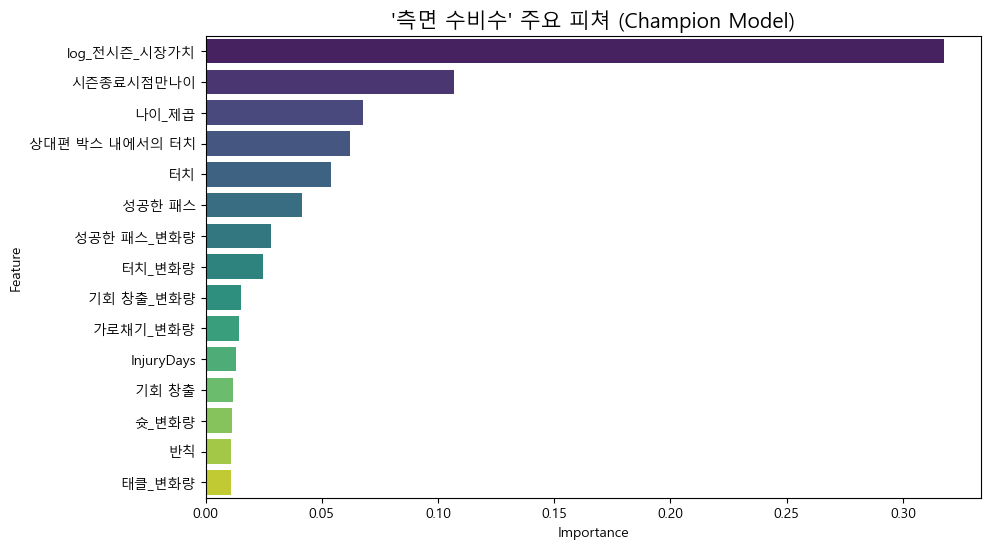


[⬆️ 과대평가 TOP 5]
                    선수명       실제_가치       예측_가치          오차
484   raphaël guerreiro  21000000.0  34687660.0  13687660.0
3233      lucas vázquez  13333333.0  25258612.0  11925279.0
4675     thomas meunier   8250000.0  19441396.0  11191396.0
3540    daniel carvajal  20250000.0  30998952.0  10748952.0
1199       filip kostic  21333333.0  31452004.0  10118671.0

[⬇️ 과소평가 TOP 5]
                         선수명        실제_가치       예측_가치          오차
7710  trent alexander-arnold  106333333.0  59017632.0 -47315701.0
1516          josko gvardiol   67500000.0  38272176.0 -29227824.0
953          alphonso davies   75000000.0  45885020.0 -29114980.0
2775                 marcelo   50000000.0  24651152.0 -25348848.0
3572         marcos llorente   52500000.0  28189252.0 -24310748.0

[🎯 정확한 예측 TOP 5]
                 선수명       실제_가치         예측_가치          오차
8947       joel ward   1000000.0  9.999582e+05    -41.8125
1339   joseph scally   6666667.0  6.657077e+06  -9590.0000
6298  quentin m

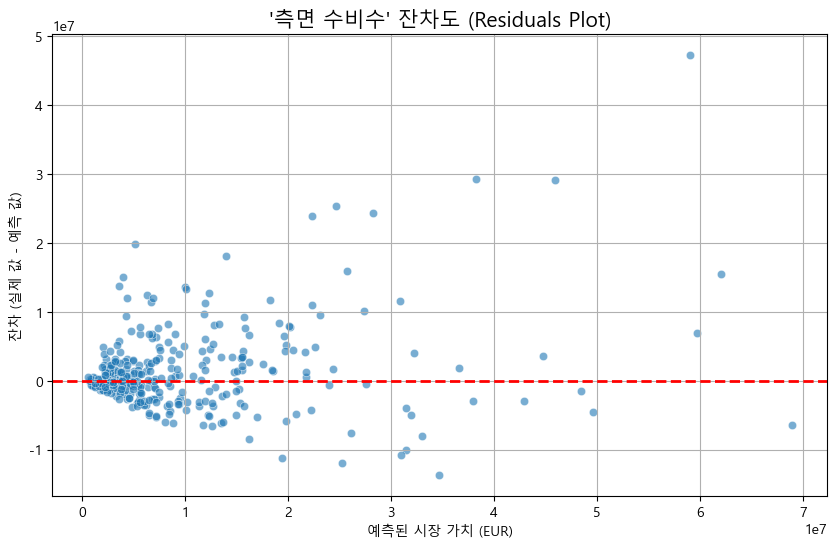


✅ 모든 분석이 완료되었습니다!


In [5]:
# Cell 5: 최종 모델 학습 및 분석 실행
print("\n" + "="*80)
print("✨ 포지션별 챔피언 모델 학습 및 분석 시작 ✨")
print("="*80)

final_results_storage = {}

position_groups = sorted(df['포지션_그룹'].unique())

for group in position_groups:
    print("\n" + "="*80)
    print(f"✨ {group} 분석 중... ✨")
    print("="*80)

    group_df = df[df['포지션_그룹'] == group].copy()
    if len(group_df) < 20: 
        print(f"⚠️ 데이터 부족 ({len(group_df)}개)으로 건너뜁니다.")
        continue

    # 데이터 준비
    y = group_df['log_현재_시장가치']
    
    cols_to_drop = [
        '리그', 'TM_시장가치_EUR', '전시즌_시장가치_EUR', '시장가치_변화량', 'log_현재_시장가치',
        '선수명', '생년월일', 'source_file', 'name_key', '시즌', '시즌코드', 
        '포지션', '포지션_그룹'
    ] + [f'전시즌_{stat}' for stat in stats_for_change]
    
    cols_to_drop = [c for c in cols_to_drop if c in group_df.columns]
    X = group_df.drop(columns=cols_to_drop).fillna(0)
    
    # 학습/테스트 분리
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 스케일링
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # 모델 학습
    champion_params = best_params_per_position.get(group)
    if not champion_params:
        print(f"⚠️ '{group}'에 대한 파라미터가 정의되지 않아 건너뜁니다.")
        continue

    print(f"'{group}' 챔피언 모델 학습 시작...")
    final_model = XGBRegressor(objective='reg:squarederror', **champion_params, random_state=42, n_jobs=-1)
    final_model.fit(X_train_scaled, y_train, verbose=False)

    # 예측 및 평가
    log_y_pred = final_model.predict(X_test_scaled)
    y_pred = np.expm1(log_y_pred)
    y_test_orig = np.expm1(y_test)
    
    rmse = np.sqrt(mean_squared_error(y_test_orig, y_pred))
    r2 = r2_score(y_test, log_y_pred)
    
    print(f"\n[📊 모델 성능 평가]")
    print(f"  - R-squared: {r2:.2%}")
    print(f"  - RMSE: {rmse:,.0f} EUR")

    # 피쳐 중요도 시각화
    importances = final_model.feature_importances_
    feature_names = X.columns
    imp_df = pd.DataFrame(sorted(zip(importances, feature_names), reverse=True), columns=['Importance', 'Feature']).head(15)
    
    print(f"\n[📈 주요 피쳐 Top 15]")
    print(imp_df)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=imp_df, palette='viridis')
    plt.title(f"'{group}' 주요 피쳐 (Champion Model)", fontsize=15)
    plt.show()

    # 오차 분석
    results_df = X_test.copy()
    # name_key가 없으면 선수명 사용
    if 'name_key' in df.columns:
        results_df['선수명'] = df.loc[X_test.index, 'name_key']
    else:
        results_df['선수명'] = df.loc[X_test.index, '선수명']
    
    results_df['실제_가치'] = y_test_orig
    results_df['예측_가치'] = y_pred
    results_df['오차'] = results_df['예측_가치'] - results_df['실제_가치']
    results_df['오차_절대값'] = results_df['오차'].abs()
    
    # --- [핵심 수정] error_analysis_df 정의 및 저장 ---
    error_analysis_df = results_df.copy() # 분석용 데이터프레임 생성
    
    print("\n[⬆️ 과대평가 TOP 5]")
    print(error_analysis_df.sort_values(by='오차', ascending=False)[['선수명', '실제_가치', '예측_가치', '오차']].head(5))
    
    print("\n[⬇️ 과소평가 TOP 5]")
    print(error_analysis_df.sort_values(by='오차', ascending=True)[['선수명', '실제_가치', '예측_가치', '오차']].head(5))
    
    print("\n[🎯 정확한 예측 TOP 5]")
    print(error_analysis_df.sort_values(by='오차_절대값', ascending=True)[['선수명', '실제_가치', '예측_가치', '오차']].head(5))

    # 잔차도
    residuals = y_test_orig - y_pred
    plt.figure(figsize=(10, 6))
    sns.scatterplot(x=y_pred, y=residuals, alpha=0.6)
    plt.axhline(y=0, color='r', linestyle='--', lw=2)
    plt.title(f"'{group}' 잔차도 (Residuals Plot)", fontsize=15)
    plt.xlabel("예측된 시장 가치 (EUR)")
    plt.ylabel("잔차 (실제 값 - 예측 값)")
    plt.grid(True)
    plt.show()
    
    final_results_storage[group] = {
        'model': final_model,
        'scaler': scaler,
        'X_columns': X.columns,
        'r2': r2, 
        'rmse': rmse, 
        'feature_importance': imp_df,
        'error_analysis': error_analysis_df # 이제 정상적으로 저장됨
    }

print("\n✅ 모든 분석이 완료되었습니다!")

In [6]:
# Cell 7: 사용자 입력 기반 선수 가치 예측 함수

def predict_custom_player(position, age, prev_market_value, injury_days, current_stats, prev_stats=None):
    """ 임의의 선수 데이터를 입력받아 예상 시장 가치와 90% 신뢰 구간을 예측 """
    
    # 1. 포지션 그룹 확인
    group = group_position_detailed(position)
    if group == '기타' or group not in final_results_storage:
        print(f"❌ 죄송합니다. '{position}' ({group}) 포지션에 대한 예측 모델이 없습니다."); return

    print(f"\n🔍 '{position}' ({group} 모델) 선수의 가치를 예측합니다...")
    
    # 2. 모델 및 정보 로드 & 로그 스케일 RMSE 계산
    model_info = final_results_storage[group]
    model, scaler, feature_names = model_info['model'], model_info['scaler'], model_info['X_columns']
    
    error_df = model_info['error_analysis']
    y_true_log = np.log1p(error_df['실제_가치'].clip(lower=0))
    y_pred_log = np.log1p(error_df['예측_가치'].clip(lower=0))
    log_rmse = np.sqrt(mean_squared_error(y_true_log, y_pred_log))

    # 3. 입력 데이터 생성 및 기본 정보 입력
    input_data = pd.DataFrame(0, index=[0], columns=feature_names)
    for stat, value in current_stats.items():
        if stat in input_data.columns: input_data[stat] = value
            
    if 'InjuryDays' in input_data.columns: input_data['InjuryDays'] = injury_days
    if '시즌종료시점만나이' in input_data.columns: input_data['시즌종료시점만나이'] = age
    
    # 4. 피쳐 엔지니어링
    if '나이_제곱' in input_data.columns: input_data['나이_제곱'] = age ** 2
    if 'log_전시즌_시장가치' in input_data.columns: input_data['log_전시즌_시장가치'] = np.log1p(prev_market_value)

    if prev_stats is None: prev_stats = {}
    stats_for_change = [c for c in ['득점', '어시스트', '기회 창출', '슛', '태클 성공', '가로채기', '터치', '성공한 패스'] if f'{c}_변화량' in input_data.columns]
    
    for stat in stats_for_change:
        input_data[f'{stat}_변화량'] = current_stats.get(stat, 0) - prev_stats.get(stat, 0)
            
    if '나이x득점_변화량' in input_data.columns:
        input_data['나이x득점_변화량'] = age * (current_stats.get('득점', 0) - prev_stats.get('득점', 0))
    if '슛_대비_득점율' in input_data.columns:
        shots = current_stats.get('슛', 0)
        input_data['슛_대비_득점율'] = current_stats.get('득점', 0) / shots if shots > 0 else 0

    # 5. 스케일링 및 예측
    try:
        input_scaled = scaler.transform(input_data)
    except Exception as e:
        print(f"⚠️ 스케일링 오류: {e}"); return

    log_pred = model.predict(input_scaled)[0]
    pred_value = np.expm1(log_pred)
    
    # 결과 출력
    print("="*60)
    print(f"📊 선수 가치 예측 결과 ({position})")
    print("="*60)
    print(f"💰 예상 시장 가치: {pred_value:,.0f} EUR")
    print(f"   (한화 약 {pred_value * 1450 / 100000000:,.1f} 억 원)")

In [7]:
# Cell 8: 25/26 시즌 선수 가치 예측 (모든 스탯 명시적 입력)

print("\n" + "="*80)
print("⚽ 2025-2026 시즌 선수 가치 정밀 예측 시뮬레이션 ⚽")
print("="*80)

# --- 1. 엔조 페르난데스 (Enzo Fernández) ---
# 시나리오: 핵심 스탯 소폭 상승, 나머지 스탯 유지

# 24/25 시즌 실제 스탯
enzo_2425_stats = {
    '득점': 0.18, '슛': 1.62, '유효 슈팅': 0.61, '어시스트': 0.21,
    '성공한 패스': 45.49, '패스 정확도': 83.7, '정확한 긴 패스': 3.02, '롱 패스 정확도': 57.6,
    '기회 창출': 2.41, '성공한 크로스': 0.79, '크로스 정확도': 23.9,
    '드리블 성공': 55.3, '드리블 성공.1': 55.3,
    '터치': 71.09, '상대편 박스 내에서의 터치': 2.6,
    '볼 뺏김': 0.86, '획득한 파울': 1.65,
    '태클 성공': 1.99, '볼 경합 성공': 4.86, '볼 경합 성공 %': 46.6,
    '공중 볼 경합 성공': 0.46, '공중 볼 경합 성공 %': 31.3,
    '가로채기': 0.4, '막힌 슛': 0.21, '반칙': 1.59, '회복': 4.77,
    '공격 지역 점유율': 0.73, '드리블로 제침': 1.62, '경고': 0.24, '퇴장': 0
}

# 25/26 시즌 예상 스탯 (모든 항목 명시)
enzo_2526_stats = {
    # [상승] 공격 포인트 및 플레이메이킹
    '득점': 0.25, '어시스트': 0.30, '기회 창출': 2.8,
    '슛': 1.8, '유효 슈팅': 0.7,
    '성공한 패스': 50.0, '터치': 75.0, '상대편 박스 내에서의 터치': 3.0,
    
    # [유지] 패스 및 크로스 정확도
    '패스 정확도': 84.0, '정확한 긴 패스': 3.1, '롱 패스 정확도': 58.0,
    '성공한 크로스': 0.8, '크로스 정확도': 24.0,
    
    # [유지] 드리블 및 볼 소유
    '드리블 성공': 55.0, '드리블 성공.1': 55.0,
    '볼 뺏김': 0.8, '획득한 파울': 1.7,
    
    # [상승] 수비 기여도 및 활동량
    '태클 성공': 2.2, '가로채기': 0.5, '회복': 5.2, '공격 지역 점유율': 0.8,
    
    # [유지] 경합 및 기타
    '볼 경합 성공': 4.9, '볼 경합 성공 %': 47.0,
    '공중 볼 경합 성공': 0.5, '공중 볼 경합 성공 %': 32.0,
    '막힌 슛': 0.2, '반칙': 1.5, '드리블로 제침': 1.6, '경고': 0.2, '퇴장': 0
}

predict_custom_player(
    position='중앙 수비형 미드필더',
    age=25, # 24 -> 25세
    prev_market_value=75000000,
    injury_days=5, 
    current_stats=enzo_2526_stats,
    prev_stats=enzo_2425_stats
)


# --- 2. 해리 케인 (Harry Kane) ---
# 시나리오: 득점 및 연계 능력 대폭 상승

# 24/25 시즌 실제 스탯
kane_2425_stats = {
    '득점': 0.98, '슛': 4.29, '유효 슈팅': 2.03, '어시스트': 0.3,
    '성공한 패스': 18.76, '패스 정확도': 80.7, '정확한 긴 패스': 1.54, '롱 패스 정확도': 70.7,
    '기회 창출': 1.32, '성공한 크로스': 0.15, '크로스 정확도': 30.8,
    '드리블 성공': 44.2, '드리블 성공.1': 44.2,
    '터치': 37.11, '상대편 박스 내에서의 터치': 6.52,
    '볼 뺏김': 0.83, '획득한 파울': 0.79,
    '태클 성공': 0.49, '볼 경합 성공': 3.24, '볼 경합 성공 %': 50.9,
    '공중 볼 경합 성공': 1.13, '공중 볼 경합 성공 %': 60.0,
    '가로채기': 0.08, '막힌 슛': 0.08, '반칙': 0.34, '회복': 2.3,
    '공격 지역 점유율': 0.49, '드리블로 제침': 0.15, '경고': 0.19, '퇴장': 0
}

# 25/26 시즌 예상 스탯 (모든 항목 명시)
kane_2526_stats = {
    # [대폭 상승] 득점 및 슈팅
    '득점': 1.5, '슛': 5.5, '유효 슈팅': 2.8,
    
    # [상승] 연계 및 찬스 메이킹 (Harry Kane Role)
    '어시스트': 0.5, '기회 창출': 2.5,
    '성공한 패스': 25.0, '패스 정확도': 82.0,
    '정확한 긴 패스': 2.0, '롱 패스 정확도': 75.0,
    
    # [상승] 박스 장악력
    '터치': 45.0, '상대편 박스 내에서의 터치': 9.0,
    
    # [유지] 드리블 및 크로스
    '드리블 성공': 45.0, '드리블 성공.1': 45.0,
    '성공한 크로스': 0.2, '크로스 정확도': 31.0,
    
    # [유지] 수비 및 경합 (공격수는 이 부분이 낮아도 무방)
    '태클 성공': 0.4, '가로채기': 0.05, '회복': 2.0, '공격 지역 점유율': 0.8,
    '볼 뺏김': 0.8, '획득한 파울': 0.8,
    '볼 경합 성공': 3.0, '볼 경합 성공 %': 50.0,
    '공중 볼 경합 성공': 1.0, '공중 볼 경합 성공 %': 60.0,
    '막힌 슛': 0.1, '반칙': 0.3, '드리블로 제침': 0.1, '경고': 0.1, '퇴장': 0
}

predict_custom_player(
    position='스트라이커', 
    age=32, 
    prev_market_value=82500000, 
    injury_days=0, 
    current_stats=kane_2526_stats, 
    prev_stats=kane_2425_stats
)


⚽ 2025-2026 시즌 선수 가치 정밀 예측 시뮬레이션 ⚽

🔍 '중앙 수비형 미드필더' (수비형 미드필더 모델) 선수의 가치를 예측합니다...
📊 선수 가치 예측 결과 (중앙 수비형 미드필더)
💰 예상 시장 가치: 69,636,128 EUR
   (한화 약 1,009.7 억 원)

🔍 '스트라이커' (스트라이커 모델) 선수의 가치를 예측합니다...
📊 선수 가치 예측 결과 (스트라이커)
💰 예상 시장 가치: 65,513,732 EUR
   (한화 약 949.9 억 원)


In [ ]:
# Cell 9: 가상의 유망주 스텝업 시뮬레이션 (중앙 수비수)

print("\n" + "="*80)
print("🛡️ 가상의 중앙 수비수 유망주(20세 -> 21세) 스텝업 시뮬레이션 🛡️")
print("   : 1,500만 유로 유망주가 '월드클래스 수비수'로 성장한다면?")
print("="*80)

# --- 가상의 선수 ----

# 1. 지난 시즌 (24/25): 20세, 잠재력은 있지만 평범한 스탯
# (수비는 나쁘지 않으나 빌드업 관여가 적고 실수가 있는 편)
young_cb_2425_stats = {
    '득점': 0.0, '어시스트': 0.0, '기회 창출': 0.1, '슛': 0.2, '유효 슈팅': 0.0,
    '성공한 패스': 30.0, '패스 정확도': 82.0, '정확한 긴 패스': 1.5, '롱 패스 정확도': 40.0,
    '성공한 크로스': 0.0, '크로스 정확도': 0.0,
    '드리블 성공': 0.1, '드리블 성공.1': 50.0,
    '터치': 45.0, '상대편 박스 내에서의 터치': 0.3, # 세트피스 가담 적음
    '볼 뺏김': 0.5, '획득한 파울': 0.5,
    '태클 성공': 1.2, '볼 경합 성공': 3.0, '볼 경합 성공 %': 55.0,
    '공중 볼 경합 성공': 2.0, '공중 볼 경합 성공 %': 50.0,
    '가로채기': 0.8, '막힌 슛': 0.1, '반칙': 1.2, '회복': 3.0,
    '공격 지역 점유율': 0.1, '드리블로 제침': 0.5, '경고': 0.3, '퇴장': 0
}

# 2. 이번 시즌 (25/26): 21세, 수비의 핵이자 빌드업 리더로 성장
young_cb_2526_stats = young_cb_2425_stats.copy()
young_cb_2526_stats.update({
    # [빌드업 능력 폭발] 가장 중요한 피쳐들
    '성공한 패스': 65.0,    # 패스 횟수 2배 이상 증가
    '패스 정확도': 92.0,    # 최상급 패스 성공률
    '터치': 85.0,          # 경기 관여도 대폭 상승
    '정확한 긴 패스': 4.5,  # 롱패스 장착
    
    # [수비력 완성]
    '태클 성공': 2.5,      # 태클 괴물
    '가로채기': 2.0,       # 인터셉트 능력 향상
    '회복': 6.0,           # 넓은 커버 범위
    '공중 볼 경합 성공': 3.5, '공중 볼 경합 성공 %': 65.0, # 제공권 장악
    
    # [공격 가담]
    '득점': 0.1,           # 헤더 골 
    '상대편 박스 내에서의 터치': 1.5, # 세트피스 위협적
    '슛': 0.5, '유효 슈팅': 0.2
})

predict_custom_player(
    position='중앙 수비수', 
    age=21,              # 20세 -> 21세
    prev_market_value=15000000, # 작년 몸값 1500만 유로
    injury_days=0,       # 부상 없음
    current_stats=young_cb_2526_stats, # 스텝업한 이번 시즌
    prev_stats=young_cb_2425_stats     # 평범했던 작년 시즌
)


🛡️ 가상의 중앙 수비수 유망주(20세 -> 21세) 스텝업 시뮬레이션 🛡️
   : 1,500만 유로 유망주가 '월드클래스 수비수'로 성장한다면?

🔍 '중앙 수비수' (중앙 수비수 모델) 선수의 가치를 예측합니다...
📊 선수 가치 예측 결과 (중앙 수비수)
💰 예상 시장 가치: 21,466,616 EUR
   (한화 약 311.3 억 원)
